# Block 3: Preprocessing & Basic Segmentation

In blocks 1 & 2, we looked at what images are, and how they can be shown and handled in Python. In the following block, we dive more deeply into how to process an image post-acquisition.

A common goal in bioimage analysis is to identify structures we care about, and ignore things from the background. We may want to detect the number of cells or nuclei in an image, or count the number of fluorescent spots and measure their properties.

A simple workflow is: **threshold → clean → measure**. We start with thresholding to separate foreground from background and get a rough idea of interesting objects. Then we use filtering and cleanup (e.g., smoothing or removing small objects) to reduce noise and fix small errors. After that, we can create objects (ROIs) and measure size, shape, and intensity.

All code cells are clearly commented to explain what new lines do!

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, io, morphology, measure
import pandas as pd
import tifffile
from ipywidgets import interact, widgets
from skimage import exposure


## Thresholding

Thresholding is a simple technique used to define a boundary at which pixels are classified into background and foreground. In general, pixels brighter than the threshold value are considered **foreground**, while pixels dimmer than the value are considered **background**. This results in a binary image, with all foreground pixels being classified as 1 (or 255), and all background pixels being considered 0. 

Thresholding is often the first step in image analysis. Once we seperate the image based upon this simple criteria, the computer can identify all objects in the foreground as objects of interest.

### Manual Thresholding
In the following code cell, we examine the image `blobs.tif` and interactively threshold the image. A convenient tool to set thresholds is to examine the actual intensities present in the image, which we can do by examining the image histogram.

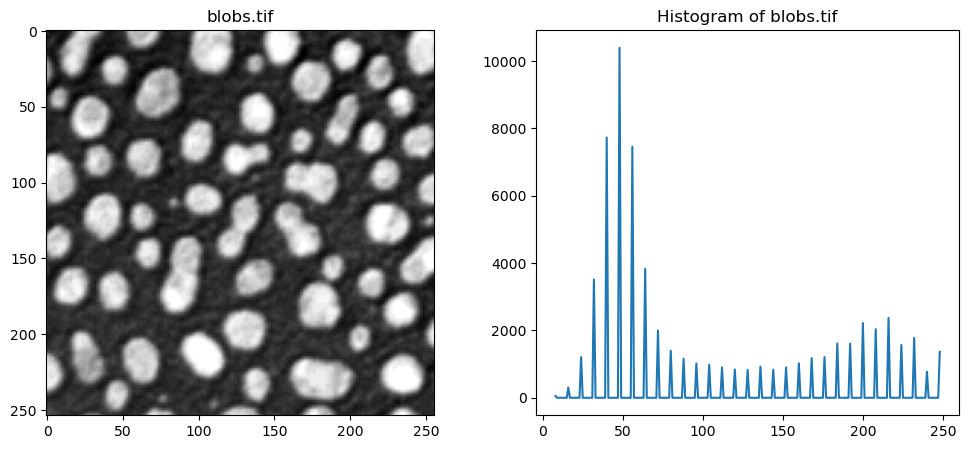

In [51]:
# Open blobs.tif
img_blobs = tifffile.imread("../../data/blobs.tif")

# Plotting code for histogram
hist, bin_centers = exposure.histogram(img_blobs)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_blobs, cmap="gray")
ax[0].set_title("blobs.tif")
ax[1].set_title("Histogram of blobs.tif")
ax[1].plot(bin_centers, hist)
plt.show()

Use the slider in the following execution to find a good threshold to separate the blobs from the background signal.

In [31]:
@interact(threshold=(0, 255, 1))
def apply_threshold(threshold=128):
    # Step 1 — Select all pixels brighter than the chosen threshold
    bright_pixels = img_blobs > threshold

    # Step 2 — Convert the grayscale image to RGB so we can add colors
    overlay_image = np.stack([img_blobs] * 3, axis=-1)

    # Step 3 — Color the detected pixels red
    overlay_image[bright_pixels] = [255, 0, 0]

    # Step 4 — Show the original image and the detected pixels
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].imshow(img_blobs, cmap="gray")
    ax[0].set_title("Original image")
    ax[0].axis("off")

    ax[1].imshow(overlay_image)
    ax[1].set_title(f"Pixels brighter than {threshold}")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


interactive(children=(IntSlider(value=128, description='threshold', max=255), Output()), _dom_classes=('widget…

Manual thresholding can work well in cases where the contrast between objects and background is quite clear, like in the case above. However, this is impractical to analyse many images, or when the correct threshold is not quite as clear. 

### Otsu's Thresholding Method

Otsu's method is an **automatic thresholding** method that analyses the histogram of pixel intensities to find the most suitable threshold value. It chooses a threshold to maximize the difference between the two groups: **background** and **foreground**. This method is computationally inexpensive, and is often the first thresholding method used. 

The next cell uses `scikit-image`'s `threshold_otsu` method. This gives us back a pixel intensity value, which we can then use to choose only the pixels in the image that are above it, and then display the thresholded image.

The optimal Otsu value is also printed - how far off was your manual threshold from the previous step?

Otsu's threshold: 120


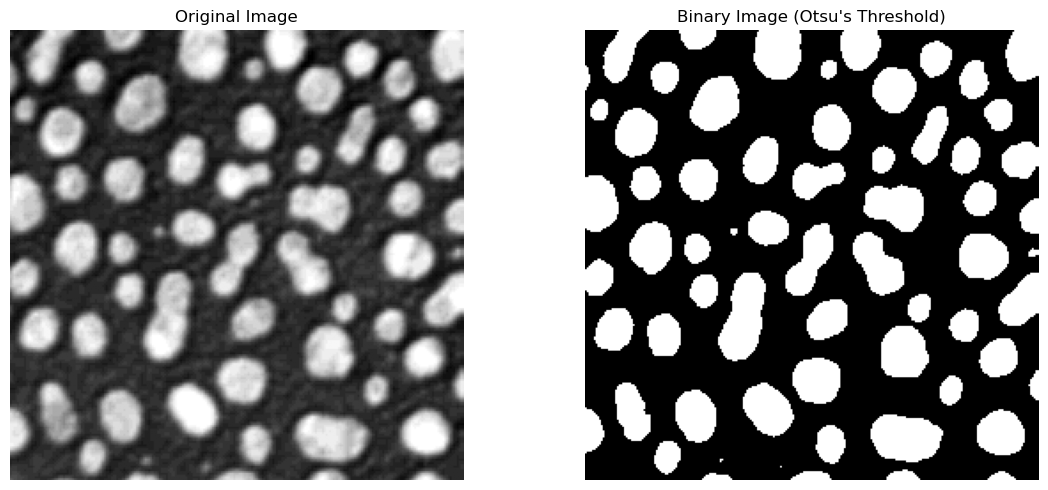

In [32]:
# Compute Otsu's threshold using filters.threshold_otsu from scikit-image
otsu_t_value_blobs = filters.threshold_otsu(img_blobs)
print(f"Otsu's threshold: {otsu_t_value_blobs}")

# Choose only the pixels brigher than the Otsu threshold
binary_image = img_blobs > otsu_t_value_blobs

# Display the original image and the binary image
# Plotting code
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_blobs, cmap="gray")
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(binary_image, cmap="gray")
ax[1].set_title("Binary Image (Otsu's Threshold)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

The returned value is a global threshold for the **entire** image. If the image has uneven illumination, or other imaging artifacts that lead to distributed intensity values, this method can struggle to find an optimal value.

### Local Adaptive Thresholding

To combat such cases, local adaptive thresholding aims to find local optima for smaller regions of the image. This allows the thresholding algorithm to adapt to changes in different parts of the image, potentially leading to much better separation of background and foreground.

Let's look at a concrete example. We take an unevenly illuminated / shaded blobs.tif that we have used till now. Visually, it is clear that a global threshold would not be able to give us a satifying result, as the edges are very dim, and would probably be counted as background pixels using Otsu's method. Let's examine the histogram.


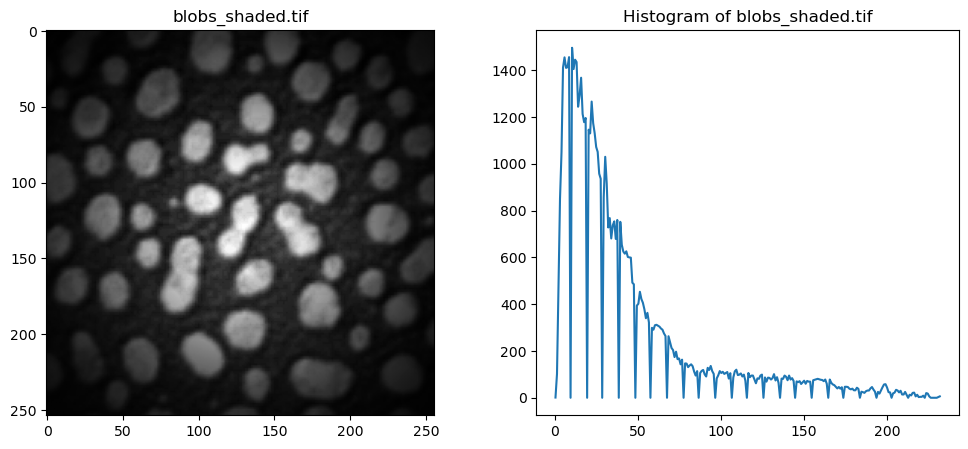

In [33]:
img_blobs_shaded = tifffile.imread("../../data/blobs_shaded.tif").astype(float)

# Show the image and its histogram side by side
hist, bin_centers = exposure.histogram(img_blobs_shaded)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_blobs_shaded, cmap="gray")
ax[0].set_title("blobs_shaded.tif")
ax[1].set_title("Histogram of blobs_shaded.tif")
ax[1].plot(bin_centers, hist)
plt.show()  

The following cell implements the local adaptive thresholding (`filters.threshold_local`). **For each pixel**, the algorithm examines at a neighborhood around it (controlled by the parameter `block_size`) and calculates a threshold based on the pixel intensities in that local window.

The block size determines a window of (`block_size` x `block_size`) means the threshold is looking at a larger window/subset of the image to compute a threshold, while a smaller block size indicates a smaller window size. Set the block_size to different values to see how that changes the thresholding output.

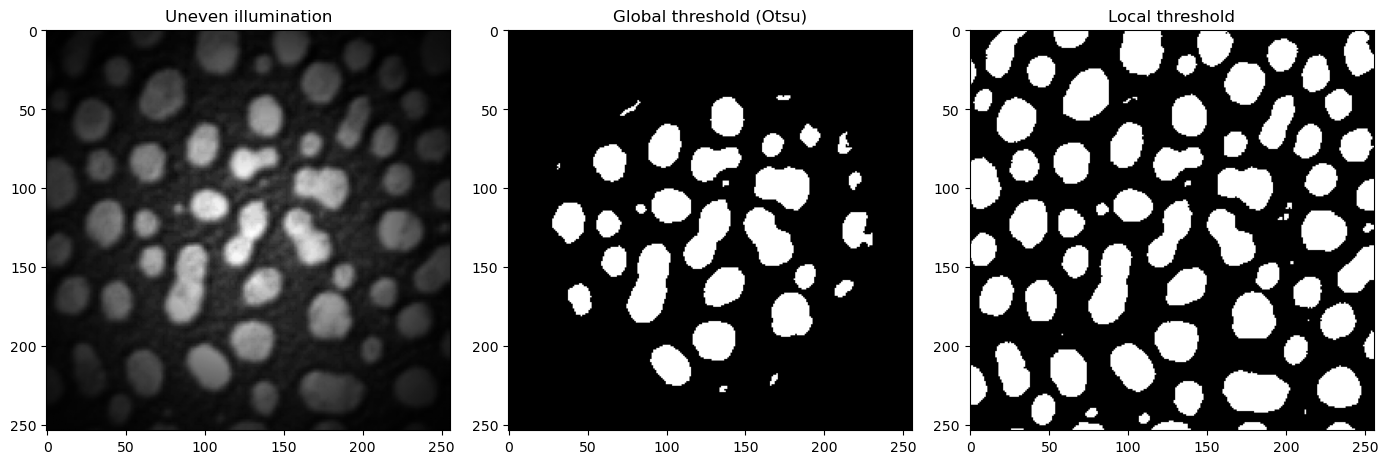

In [34]:
# Global Otsu first, for comparison
otsu_t_value_shaded = filters.threshold_otsu(img_blobs_shaded)
mask_otsu = img_blobs_shaded > otsu_t_value_shaded

# Local threshold
block_size_value = 61  # Change this value to adjust the block size 
local_t_value = filters.threshold_local(
    img_blobs_shaded, block_size=block_size_value
)  
mask_local = img_blobs_shaded > local_t_value

# ------
# Show all 3 side-by-side, plotting code
fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax[0].imshow(img_blobs_shaded, cmap="gray")
ax[0].set_title("Uneven illumination")

ax[1].imshow(mask_otsu, cmap="gray")
ax[1].set_title("Global threshold (Otsu)")

ax[2].imshow(mask_local, cmap="gray")
ax[2].set_title("Local threshold")
plt.tight_layout()
plt.show()

There are numerous other thresholding methods that can deliver better results than Otsu's method, such as Huang, Li or  Yen. These can be accessed with `filters.huang`, `filters.threshold_yen`, `filters.threshold_li`. Feel free to try these methods out in the Exercise at the end of this session.

### Questions
- When thresholding, what do "Background" and "Foreground" refer to?
- Is that different to what's commonly referred to as "background" in bio-images resulting from e.g. indirect immunofluorescence labeling?
- When would you use manual thresholding, and when an algorithm based approach (e.g."Otsu")?

## Filters

In general, we wish to enhance the signal-noise-ratio (SNR) as much as possible. If we try to segment a raw, noisy image, the computer will most likely identify the noisy pixels as objects, and interfere with our quantification of the actual signal of interest. As seen in the previous section, even slight illumination changes can lead to worse thresholding and segmentation results. By smoothing the image first, we can help the algorithms detect real structures and signals of interest.

There are multiple types of filters, such as blurring, sharpening or edge-detection filters. In the following, we'll take a closer look at blurring and sharpening filters.

### Mean / Average Filters

The average, or mean, filter is one of the simplest ways to smooth an image. This works by placing a small grid (e.g. 3x3 pixels) called a **kernel** over your image, and computing the mean of all pixel values around the center value of your grid. If there is a noisy and bright pixel in our neighborhood, we can lessen its impact on our processing by averaging over the neighboring pixels.

An illustration of a kernel operation is shown below:

![image-2.png](../../data/mean_filter_slow.gif) 

The kernel is moved over each pixel in the image. The values of the filter kernel depend on what type of kernel we are using. The average kernel of size 3x3 would look like this:

$$K = \frac{1}{9} *  \begin{bmatrix} 
1 & 1 & 1\\ 
1 & 1 & 1\\ 
1 & 1 & 1 \\
\end{bmatrix}$$


In other words: the average kernel operation adds all 9 pixels together, then divides by 9 to get the average value at each pixel entry of the image.

#### Padding

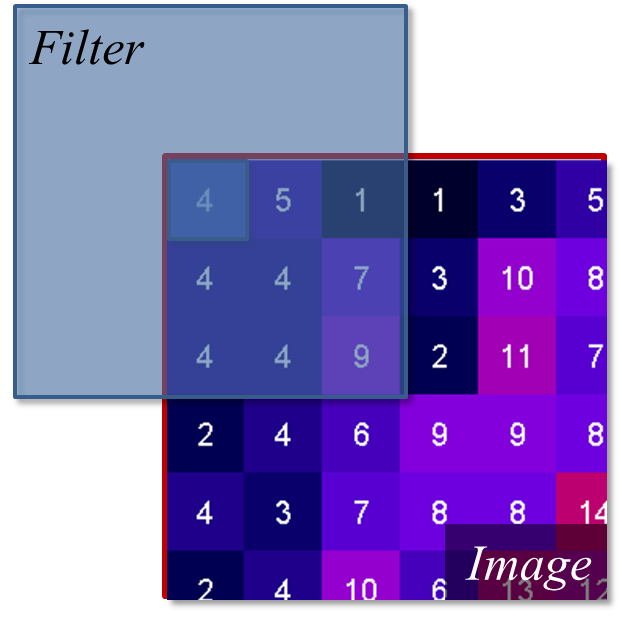

For the edge values of the image, the e.g. 3x3 kernel would "hang off" the side, meaning some of the pixels needed for the calculation are missing. To fix this, we use a technique called **padding**. We "mirror" the existing pixels at the edge to fill the gaps. This ensures the average is calculated using values similar to the real data, and that the output matches the input image size.

### The Median Filter

The median filter is another common filter used to smooth and denoise images. Instead of computing the average value of neighboring pixels, which can be susceptible to large, outlier values, the median chooses the middle value of all neighbors after sorting all pixel values.

In [11]:
noisy_blobs_image = tifffile.imread("../../data/blobs_noisy.tif")

@interact(rank_size=(2, 15, 1))
def apply_median_filter(rank_size):
    
    # Define kernel size based on slider
    footprint = morphology.footprint_rectangle((rank_size, rank_size))
    
    # Apply the kernel to the image using `filters.median(image, footprint)`
    image_median = filters.median(noisy_blobs_image, footprint)
    
    # Plotting code
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(noisy_blobs_image, cmap="gray")
    ax[0].set_title("Original: blobs_noisy.tif")
    ax[0].axis("off")
    
    ax[1].imshow(image_median, cmap="gray")
    ax[1].set_title(f"Median Filter ({rank_size}×{rank_size})")
    ax[1].axis("off")
    
    plt.tight_layout()

interactive(children=(IntSlider(value=8, description='rank_size', max=15, min=2), Output()), _dom_classes=('wi…

### The Gaussian Filter

A fundamental technique is the **Gaussian Blur**. This technique also places a kernel over the image and moves it across the image, but it handles neighboring pixels differently than the mean or median filters. Instead of treating all pixels around the center equally, the Gaussian weighs nearer pixels more heavily than pixels further away. In this case, pixels close to the center of the addressed pixel neighborhood influence the result *strongly*, while the pixels at the end of the neighborhood don't contribute as much.

In practice, the parameter that controls the filter is called $\sigma$. Smaller $\sigma$ values result in slight smoothing, while higher values result in strong blurring.

Gaussian blur is very useful for **noisy** images and can *smooth* these images very effectively.

In [52]:
@interact(sigma=(0.5,7, 0.5))
def apply_gaussian_filter(sigma):
    # Perform Gaussian filtering
    image_gaussian = filters.gaussian(image=noisy_blobs_image, sigma=sigma)

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(noisy_blobs_image, cmap="gray")
    ax[0].set_title("Original: blobs_noisy.tif")
    ax[0].axis("off")
    ax[1].imshow(image_gaussian, cmap="gray")
    ax[1].set_title(f"Gaussian Filter (sigma={sigma})")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=3.5, description='sigma', max=7.0, min=0.5, step=0.5), Output()), _dom…

Zooming in on the edges, the filter's advantages becomes clearer.

In [ ]:
h, w = noisy_blobs_image.shape

# Set up interactive parameters
@interact(
    sigma=widgets.FloatSlider(value=2.0, min=0.5, max=7.0, step=0.5, description="sigma"),
    x=widgets.IntSlider(value=75, min=0, max=w-1, step=1, description="x (pan)"),
    y=widgets.IntSlider(value=75, min=0, max=h-1, step=1, description="y (pan)"),
    half_size=widgets.IntSlider(value=25, min=5, max=100, step=5, description="zoom area")
)
def apply_gaussian_filter(sigma, x, y, half_size):
    image_gaussian = filters.gaussian(image=noisy_blobs_image, sigma=sigma)

    x0, x1 = max(0, x - half_size), min(w, x + half_size)
    y0, y1 = max(0, y - half_size), min(h, y + half_size)

    # --------
    # Plotting code
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(noisy_blobs_image[y0:y1, x0:x1], cmap="gray")
    ax[0].set_title("Original (zoomed)")
    ax[0].axis("off")
    
    ax[1].imshow(image_gaussian[y0:y1, x0:x1], cmap="gray")
    ax[1].set_title(f"Gaussian Filter (sigma={sigma})")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

interactive(children=(FloatSlider(value=2.0, description='sigma', max=7.0, min=0.5, step=0.5), IntSlider(value…

We can set the mean, median and Gaussian filters side-by-side to examine which filter has what sort of effect on our noisy image.

In [59]:
kernel_size = 5

h, w = noisy_blobs_image.shape

# Define kernel size based on rank size
footprint = morphology.footprint_rectangle((kernel_size, kernel_size))

# Apply kernel as mean filter
image_avg = filters.rank.mean(noisy_blobs_image, footprint)
# Apply kernel as median filter
image_median = filters.median(noisy_blobs_image, footprint)

@interact(
    sigma=widgets.FloatSlider(value=1.5, min=0.5, max=7.0, step=0.5, description="sigma"),
    x=widgets.IntSlider(value=75, min=0, max=w-1, step=1, description="x (pan)"),
    y=widgets.IntSlider(value=75, min=0, max=h-1, step=1, description="y (pan)"),
    half_size=widgets.IntSlider(value=25, min=5, max=100, step=5, description="zoom area")
)
def show_filters(x, y, half_size, sigma):
    x0, x1 = max(0, x - half_size), min(w, x + half_size)
    y0, y1 = max(0, y - half_size), min(h, y + half_size)
    image_gaussian = filters.gaussian(image=noisy_blobs_image, sigma=sigma)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image_avg[y0:y1, x0:x1], cmap="gray")
    ax[0].set_title(f"Mean Filter ({kernel_size}×{kernel_size})")
    ax[0].axis("off")
    ax[1].imshow(image_median[y0:y1, x0:x1], cmap="gray")
    ax[1].set_title(f"Median Filter ({kernel_size}×{kernel_size})")
    ax[1].axis("off")
    ax[2].imshow(image_gaussian[y0:y1, x0:x1], cmap="gray")
    ax[2].set_title(f"Gaussian Filter (sigma={sigma})")
    ax[2].axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

interactive(children=(IntSlider(value=75, description='x (pan)', max=255), IntSlider(value=75, description='y …

### Gradient / Sharpening Filters

Smoothing filters reduce noise by e.g. averaging neighboring pixels, sharpening filters wish to enhance the edges and contours in an image and improve the contrast between background and signals of interest more sharply. In an image processing context, edges are drastic intensity changes that are typically found at biological boundaries, such as between cell and nucleus, or cell and background.

#### Sobel Filter

The Sobel filter is a classic edge-detection method that highlights strong intensity changes in an image.

It computes horizontal ($G_{x}$) and vertical ($G_{y}$) gradients using fixed `3x3` kernels, then combines them into one edge magnitude image:

$$ |G| = \sqrt(Gx^2 + Gy^2)$$

Large values of $|G|$ indicate strong edges, while small values correspond to flat regions.

In practice, Sobel uses two fixed 3x3 masks:

$$G_{x} = \begin{bmatrix} 
-1 & 0 & 1\\ 
-2 & 0 & 2\\ 
-1 & 0 & 1 \\
\end{bmatrix}$$

$$G_{y} = \begin{bmatrix} 
-1 & -2 & -1\\ 
0 & 0 & 0\\ 
1 & 2 & 1 \\
\end{bmatrix}$$

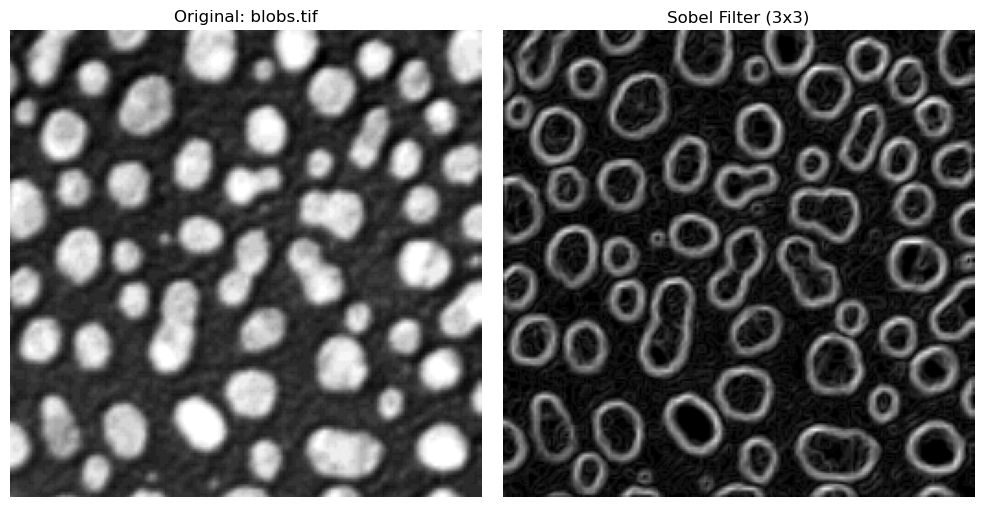

In [24]:
sobel_edges = filters.sobel(img_blobs)

# Plotting code in the same side-by-side style used above
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_blobs, cmap="gray")
ax[0].set_title("Original: blobs.tif")
ax[0].axis("off")

ax[1].imshow(sobel_edges, cmap="gray")
ax[1].set_title("Sobel Filter (3x3)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

### Questions
- When comparing the result of the mean, median and gaussian filter, what differences do you see between these methods?
- Can different filters be combined subsequently?
- Does filtering change the values of the pixels?

## Binary Images

After smoothing or filtering an image and applying a threshold, we can convert the image into a **binary** image. Such images consist only of pixel intensities 1 or 0. This was already done to visualize the thresholding from the previous section, but it is an important concept to emphasize. 

A binary image is the computer representation of splitting things into background and foreground: all pixels labelled 1 are of interest, while 0 pixels are not. In other words, thresholding transforms a grayscale/fluorescence image into a map of where interesting objects are located. Binary images are an intermediate step from viewing a raw image to analyzing objects - they tell us what pixels would belong to an interesting object.

To illustrate this, the next cell shows the original blobs image, and its binarized version using Otsu's method. We also show the actual pixel intensities of each image, where the binary image only consists of 1's or 0's.


Otsu's threshold: 120


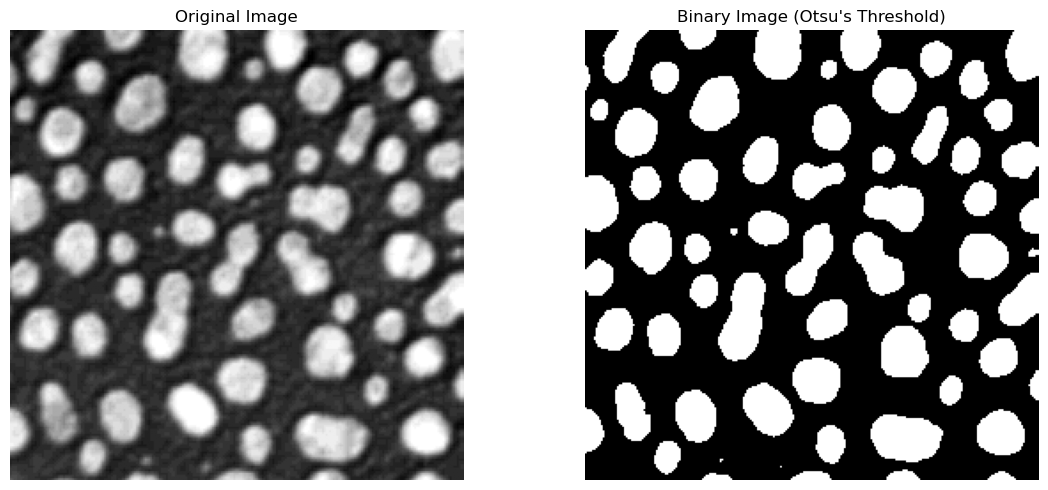

In [35]:
otsu_t_value_blobs = filters.threshold_otsu(img_blobs)
print(f"Otsu's threshold: {otsu_t_value_blobs}")

# Choose only the pixels brigther than the Otsu threshold
binary_image = img_blobs > otsu_t_value_blobs

# Display the original image and the binary image
# Plotting code
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(img_blobs, cmap="gray")
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(binary_image, cmap="gray")
ax[1].set_title("Binary Image (Otsu's Threshold)")
ax[1].axis("off")
plt.tight_layout()
plt.show()


### Masking


A mask is a way of using binary images to extract information from our raw images. A binary images tells us roughly where relevant pixel/objects are. We can then use this **mask** to overlay the binary image on our raw image, and extract information from our raw data depending on the pixels the binary mask tells us are relevant for our analysis or research question. Visualizing the mask also helps in qualitatively determining if the thresholding/segmentation is satisfactory.

A simple way of visualizing this masking step is to color our binary image slightly transparently, and overlay it on our raw data. We color the mask in red, and overlay it on our raw data in the following cell. For comparison, we can take a look at the Otsu thresholding for the raw blobs and for the shaded blobs, where the result was clearly worse.

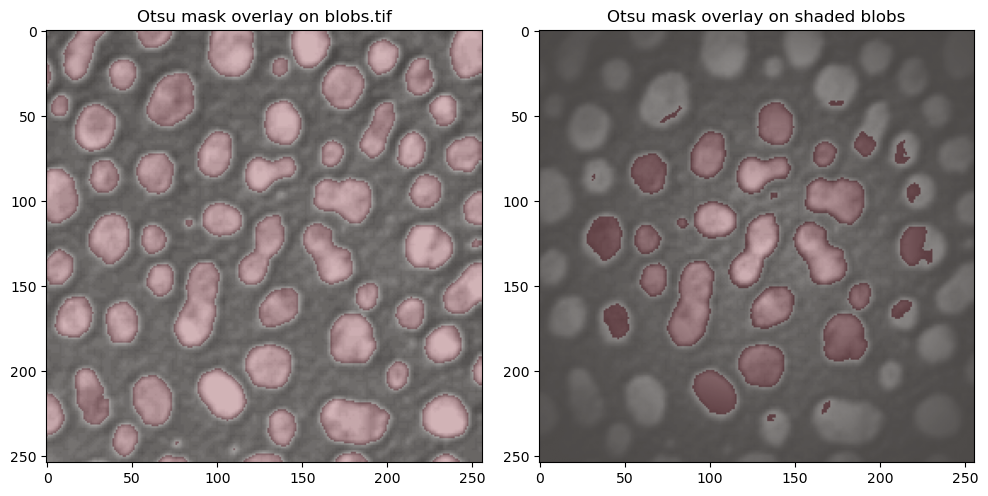

In [27]:
# Use the binary masks from before
mask_blobs = binary_image
mask_otsu = img_blobs_shaded > otsu_t_value_shaded

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Left: blobs.tif with mask overlay
ax[0].imshow(img_blobs, cmap="gray")
ax[0].imshow(mask_blobs, cmap="Reds", alpha=0.3)
ax[0].set_title("Otsu mask overlay on blobs.tif")

# Right: shaded blobs with Otsu mask overlay
ax[1].imshow(img_blobs_shaded, cmap="gray")
ax[1].imshow(mask_otsu, cmap="Reds", alpha=0.3)
ax[1].set_title("Otsu mask overlay on shaded blobs")

plt.tight_layout()
plt.show()

## Creating Objects (ROIs)

A binary image is still just a collection of pixels we have classified as being significant. The computer still does not know that **groups of these pixels** belong together and represent individual objects. For this final step of getting from raw images -> relevant objects of interest, we use a method called **Connected Components Labelling**. 

This algorithm looks for pixels that border each other in a small neighborhood and groups them together. Each group is then assigned a unique label, representing **one** object. This results in a label image, where all pixels belonging to the same object share the same label value. To count objects such as cells, we simply need to count how many labels are present in the image.

The following animation shows how a label image is created from a binary image. For computational reasons, we only need to examine the pixels above and to the left of the current pixel, as the pixel to the right will be processed next anyway. We avoid double pixel comparisons this way, leading to faster processing times.

![gif2.gif](../../data/cca_gif.gif)

After a second pass, the final label image would look like the following.

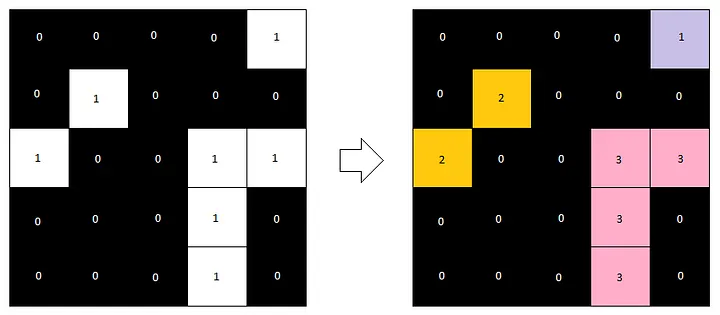

[Source]

[Source]: https://medium.com/data-science/implementing-a-connected-component-labeling-algorithm-from-scratch-94e1636554f


Now, let's take a look at what this would look like for our blobs image. `label2rgb` allows us to color the images in a way that shows each label with a different color. This allows us to visually distinguish between detected objects.

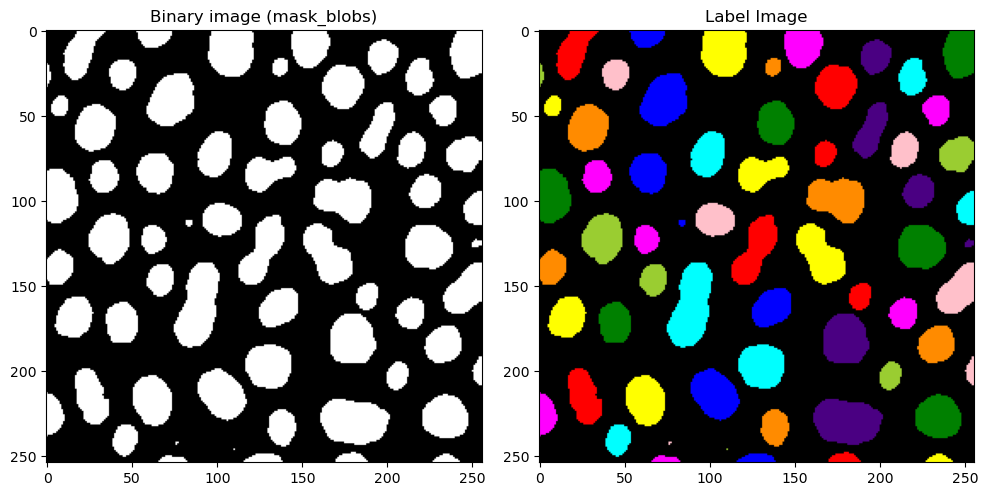

In [ ]:
from skimage.color import label2rgb

# With measure.label we can generate the label image from the binary image (mask_blobs)
label_image = measure.label(mask_blobs)

# Plotting code for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(mask_blobs, cmap="gray")
axes[0].set_title("Binary image (mask_blobs)")

# Use skimage's label2rgb to color the label image, with black background
# bg_label=0 tells the method that the backgroun is labelled 0
# and we color the background as black with bg_color=(0, 0, 0)

label_colored = label2rgb(label_image, bg_label=0, bg_color=(0, 0, 0))
axes[1].imshow(label_colored)
axes[1].set_title(f"Label Image")
plt.tight_layout()
plt.show()


### Post-Processing

We can see that we still have some very tiny blobs (coordinates 80, 100 e.g.) that we are not interested in. Once we have our signal represented as objects,we can very easily exclude objects based upon many criteria, for example, an object's area.

We can do with the regionprops method provided once again by `scikit.measure`. This module lets us measure all sorts of properties of a labelled image. To see all properties that regionprops is capable of giving us, let's take a look at what is included.


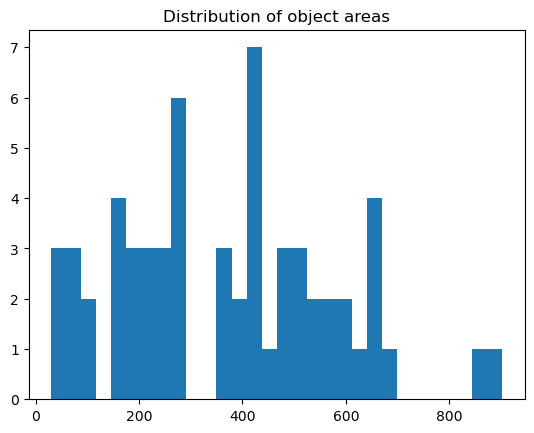

Labels to exclude (area < 30): []


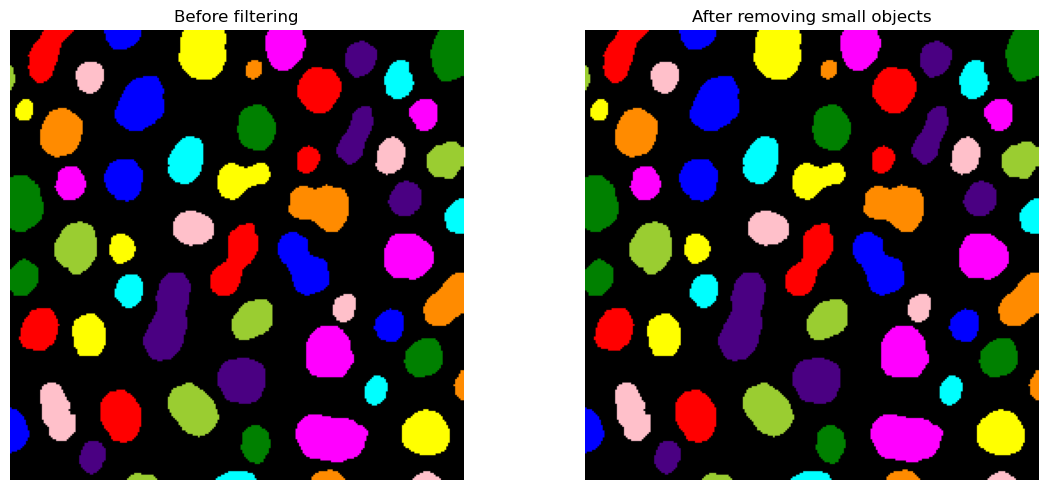

In [48]:
label_image_original = label_image.copy()

# Compute region properties using measure.regionprops, with the intensity image as img_blobs
# The label image shows the objects, while intensity image is where we want to get intensity measurements from
properties = measure.regionprops(label_image, intensity_image=img_blobs)

# Get all areas per object and plot histogram
# Each prop object in properties has an area attribute, we use a for loop to fill a list of all areas

areas = [] # make empty area list
for prop in properties:
    areas.append(prop.area) # for each prop in properties, we append the area attribute to the areas list

# Plotting histogram
plt.hist(areas, bins=30)
plt.title("Distribution of object areas")
plt.show()

# Find small objects
labels_to_exclude = [] # Empty list to find labels that are too small
for prop in properties:
    if prop.area < 30:
        # For each prop in properties, if the area is less than 30, we append the label to the labels_to_exclude list
        labels_to_exclude.append(prop.label) 
print(f"Labels to exclude (area < 30): {labels_to_exclude}")

# Remove small objects
# We choose to set the label to 0 (background) instead of deleting the label, 
# so that we can visualize the removed objects in the next step
# Read: for all labels in label_to_exclude, we set in label_image where the label is equal to that to 0 pixel value
for label in labels_to_exclude:
    label_image[label_image == label] = 0

# Create colored label images
label_colored_before = label2rgb(label_image_original, bg_label=0, bg_color=(0, 0, 0))
label_colored_after = label2rgb(label_image, bg_label=0, bg_color=(0, 0, 0))

# Show side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].imshow(label_colored_before)
ax[0].set_title("Before filtering")
ax[0].axis("off")

ax[1].imshow(label_colored_after)
ax[1].set_title("After removing small objects")
ax[1].axis("off")

plt.tight_layout()
plt.show()

### Questions

* Which step in the pipeline until this point do you think has the biggest influence on final segmentation?

### Measurements

Once we have the label image, and we've got rid of smaller objects that are not of interest, we have everything we need to begin our measurements on the raw data, as well as analyzing the objects themselves.

In the following sections, we will look into some measurement possibilites: 
- number of blobs
- average intensity per blob
- average area per of each blob


In [ ]:
# Measure properties of labeled objects
properties = measure.regionprops(label_image, img_blobs)
# properties is a list of objects, one for each detected object

# Number of detected objects, we just need the number of properties
num_objects = len(properties)
print(f"Number of blobs detected: {num_objects}")

# Collect measurements, this gives us lists of areas per objects
areas = [prop.area for prop in properties]
mean_intensities = [prop.intensity_mean for prop in properties]

# Print summary statistics
print(f"Mean blob area: {np.mean(areas):.2f} pixels")
print(f"Mean blob intensity: {np.mean(mean_intensities):.2f}")

Number of blobs detected: 60
Mean blob area: 370.05 pixels
Mean blob intensity: 191.16


## Exercise

In this section, we will use all the tools we looked at in the previous section. You can copy & paste some lines of code from the above sections easily. Googling the method/library name is also a great way of finding out about the usage and other possiblities, or asking your favourite Chatbot is also an option.

1. An image has been loaded from `skimage.data.cells3d()` - this is a fluorescence image of cells and nuclei.

2. How many channels and z-slices does the image have? Extract all channels and visualize them.

3. For the nuclei channel, find a suitable threshold (manual or automatic) and binarize the image. Visualize the binary image.

4. Create a label image from the binary image. Are there any objects you wish to remove?

5. Count how many nuclei there are present in this image, and print what the average area is of all nuclei.

6. Examine the cytoplasm channel. Could we use thresholding to create cell masks for this data?


In [ ]:
from skimage import data

img = data.cells3d()

# Print image dimensions
# ..your code here..

# Choose just the nuclei channel (channel 1, Python is 0-based!) for the next steps
# Note: this is a z-stack, so you need to choose the slice also!


# Threshold the nuclei channel and visualize the binary


# Create label image from the binary


# How many nuclei are present?


# What is the mean area of all nuclei? Hint: use np.mean(areas)


# Examine the cyto channel - can you create a mask with our methods? What are the issues you see here?

